In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import sys
# import os
# sys.path.insert(0, os.path.abspath('..'))
# from src.eda import dataset_overview, missing_values_report, check_duplicates, get_numerical_columns, skewness_report,plot_histograms,categorical_distribution,plot_categorical_distribution,correlation_heatmap,plot_boxplots,outlier_report
# # Set plot style
# sns.set_style("whitegrid")

In [2]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(
    os.path.abspath("..")
)
from src.edaf.analyzer import FraudEDA
from src.edaf.visualizer import EDAVisualizer

# EDA
## Import Data

In [3]:
df = pd.read_csv("../data/raw/data.csv")

In [4]:
eda = FraudEDA(df)

viz = EDAVisualizer(df)

## Data Overview
### Dataset Shape

In [5]:
eda.dataset_overview()

{'rows': 95662, 'columns': 16}

### Data Types

In [6]:
eda.data_types()

,dtype
TransactionId,object
BatchId,object
AccountId,object
SubscriptionId,object
CustomerId,object
CurrencyCode,object
CountryCode,int64
ProviderId,object
ProductId,object
ProductCategory,object


### Missing Values Analysis

In [7]:
eda.missing_values()

,Missing Count,Missing Percentage
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


### Duplicate Records

In [8]:
eda.duplicate_count()

np.int64(0)

## Summary Statistics

### Numerical Summary

In [9]:
eda.summary_statistics()

,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.0,256.000000,0.000000,256.0,256.0,256.0,256.0,256.0
Amount,95662.0,6717.846433,123306.797164,-1000000.0,-50.0,1000.0,2800.0,9880000.0
Value,95662.0,9900.583941,123122.087776,2.0,275.0,1000.0,5000.0,9880000.0
PricingStrategy,95662.0,2.255974,0.732924,0.0,2.0,2.0,2.0,4.0
FraudResult,95662.0,0.002018,0.044872,0.0,0.0,0.0,0.0,1.0


### Skewness

In [10]:
eda.skewness_report()

Value              51.291086
Amount             51.098490
FraudResult        22.196295
PricingStrategy     1.659057
CountryCode         0.000000
dtype: float64

## Distribution of Numerical Features

In [11]:
numerical_cols = [
    "Amount",
    "Value"
]

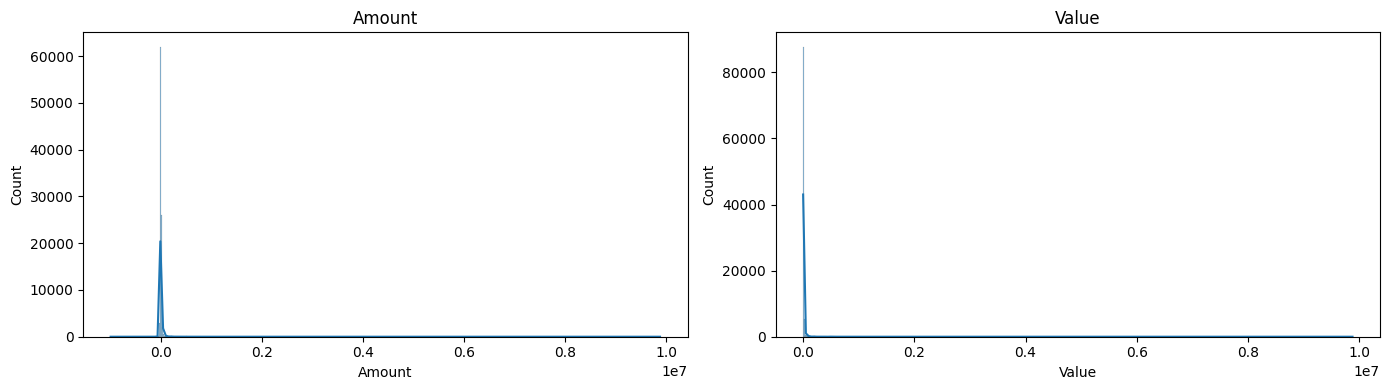

In [12]:
viz.numerical_distributions(
    numerical_cols
)

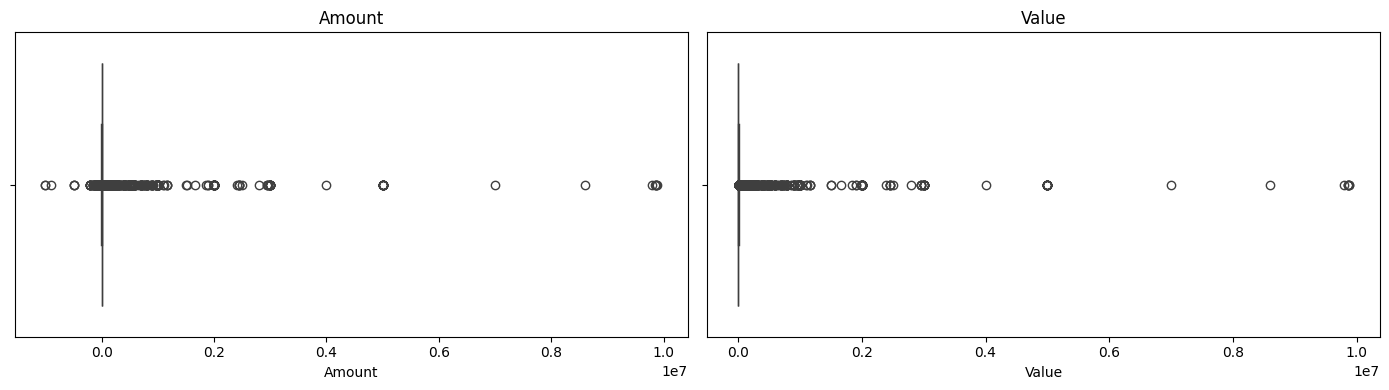

In [13]:
viz.boxplots(
    numerical_cols
)

## Distribution of Categorical Features

In [14]:
categorical_cols = [
    "ProductCategory",
    "ChannelId",
    "ProviderId",
    "PricingStrategy"
]

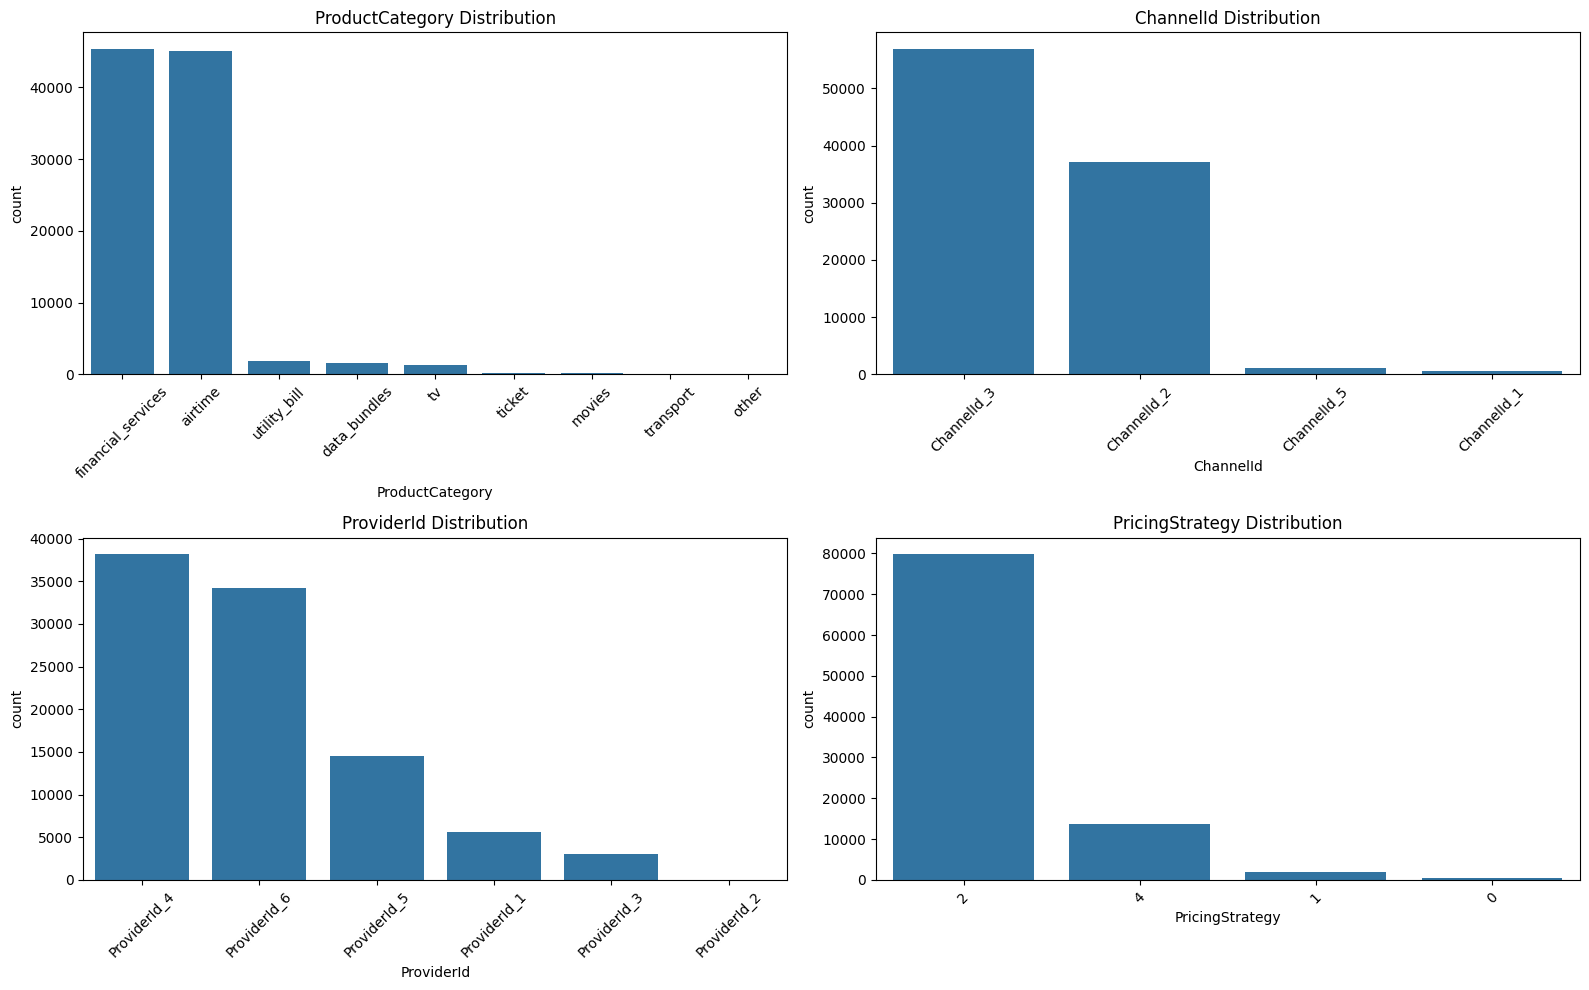

In [15]:
viz.categorical_distributions()

### Product Category

In [16]:
eda.categorical_distribution(
    "ProductCategory"
)



ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

### Channel

In [17]:
eda.categorical_distribution(
    "ChannelId"
)



ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

### Provider

In [18]:
eda.categorical_distribution(
    "ProviderId"
)

ProviderId
ProviderId_4    38189
ProviderId_6    34186
ProviderId_5    14542
ProviderId_1     5643
ProviderId_3     3084
ProviderId_2       18
Name: count, dtype: int64

In [19]:
eda.categorical_distribution(
    "PricingStrategy"
)

PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64

### Fraud Result

In [20]:
eda.fraud_distribution()



,Count,Percentage
FraudResult,,
0,95469,99.8
1,193,0.2


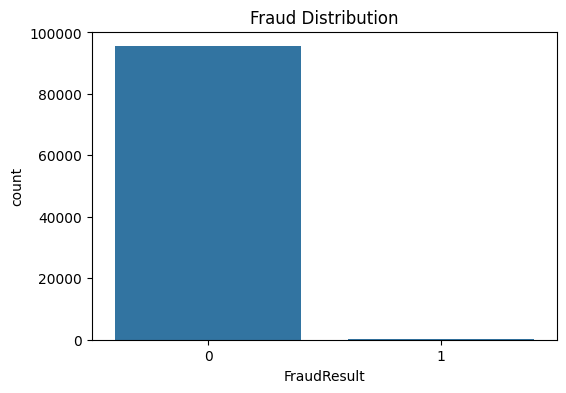

In [21]:
viz.fraud_distribution()

In [25]:
corr = [
    "Amount",
    "Value",
    "FraudResult"
]
eda.correlation_matrix(corr)

,Amount,Value,FraudResult
Amount,1.000000,0.989692,0.557370
Value,0.989692,1.000000,0.566739
FraudResult,0.557370,0.566739,1.000000


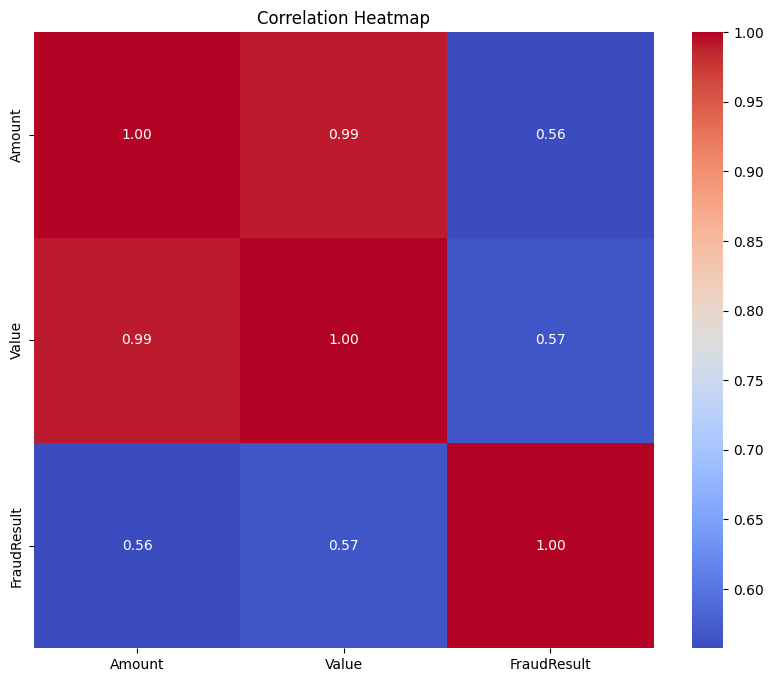

In [26]:
viz.correlation_heatmap(corr)

### Correlation Analysis

The correlation matrix was used to examine the linear relationships among the numerical variables in the dataset, namely **Amount**, **Value**, **PricingStrategy**, and **FraudResult**.

### Key Findings

- **Amount and Value** exhibited a very strong positive correlation (**0.99**). This is expected because `Value` represents the absolute transaction amount, indicating that the two variables contain largely redundant information.

- **Amount and FraudResult** showed a moderate positive correlation (**0.56**), suggesting that fraudulent transactions tend to involve larger transaction amounts.

- **Value and FraudResult** also demonstrated a moderate positive correlation (**0.57**), reinforcing the observation that higher-value transactions are more likely to be associated with fraudulent activity.

- **PricingStrategy** displayed very weak correlations with other numerical variables:
  - Amount: **-0.06**
  - Value: **-0.02**
  - FraudResult: **-0.03**

  These near-zero values indicate little direct linear relationship with transaction value or fraud occurrence.

- **CountryCode** was excluded from the correlation analysis because it contains only a single unique value, resulting in zero variance and providing no meaningful statistical information.

### Business Interpretation

The results suggest that transaction size, represented by **Amount** and **Value**, is an important indicator of fraud risk and may be a valuable predictor in credit risk modeling. In contrast, **PricingStrategy** appears to have limited predictive value when considered independently. Additionally, the strong correlation between **Amount** and **Value** indicates potential redundancy, which should be considered during feature selection and model development.

## Outlier Detection

In [24]:
eda.outlier_report()

,Outlier Count,Outlier Percentage
Amount,24441.0,25.55
Value,9021.0,9.43


Outlier analysis revealed a substantial number of extreme values in the **Amount** and **Value** features, consistent with their highly right-skewed distributions. The boxplots showed that while most transactions are relatively small, a small proportion of transactions have exceptionally large values.


From a business perspective, these outliers likely represent high-value transactions, large merchant payments, or potentially fraudulent activities rather than data errors. Therefore, they should be retained for analysis, although transformation techniques such as logarithmic scaling may be applied to reduce skewness and improve model performance.

Variables such as **PricingStrategy** and **FraudResult** were excluded from interpretation since they represent categorical and binary data rather than continuous measurements.